<a href="https://colab.research.google.com/github/Brayan0928/Amigo-Secreto/blob/main/challenge2.2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
pd.read_json('/content/TelecomX_Data.json')

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
...,...,...,...,...,...,...
7262,9987-LUTYD,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
7263,9992-RRAMN,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7264,9992-UJOEL,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7265,9993-LHIEB,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Two year', 'PaperlessBilling': '..."


Dimensiones del dataset: (7267, 21)
   customerID Churn customer.gender  customer.SeniorCitizen customer.Partner  \
0  0002-ORFBO    No          Female                       0              Yes   
1  0003-MKNFE    No            Male                       0               No   
2  0004-TLHLJ   Yes            Male                       0               No   
3  0011-IGKFF   Yes            Male                       1              Yes   
4  0013-EXCHZ   Yes          Female                       1              Yes   

  customer.Dependents  customer.tenure phone.PhoneService phone.MultipleLines  \
0                 Yes                9                Yes                  No   
1                  No                9                Yes                 Yes   
2                  No                4                Yes                  No   
3                  No               13                Yes                  No   
4                  No                3                Yes                  No 

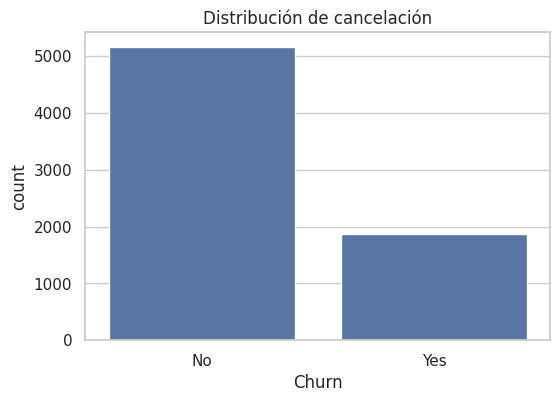

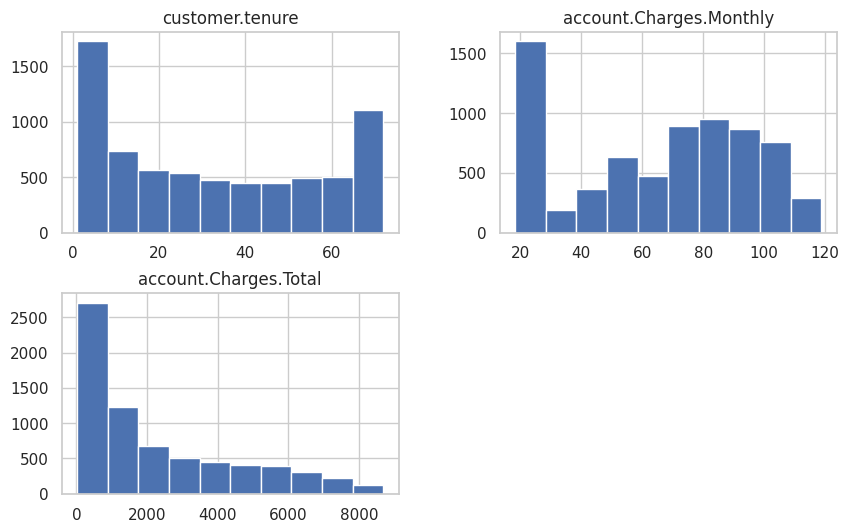

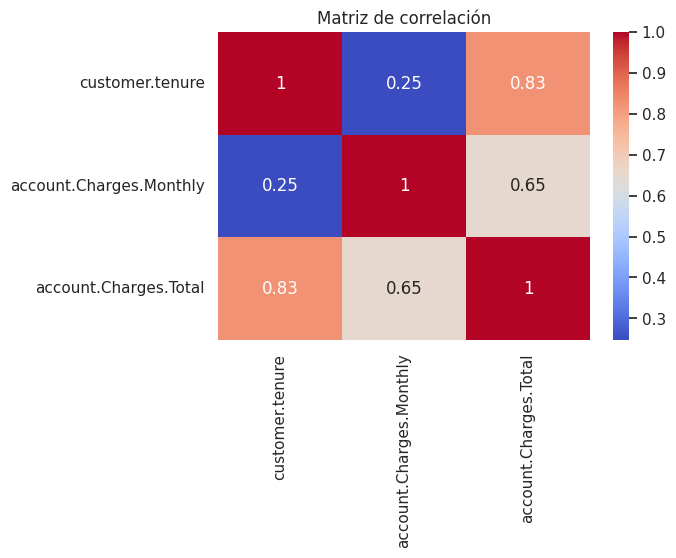

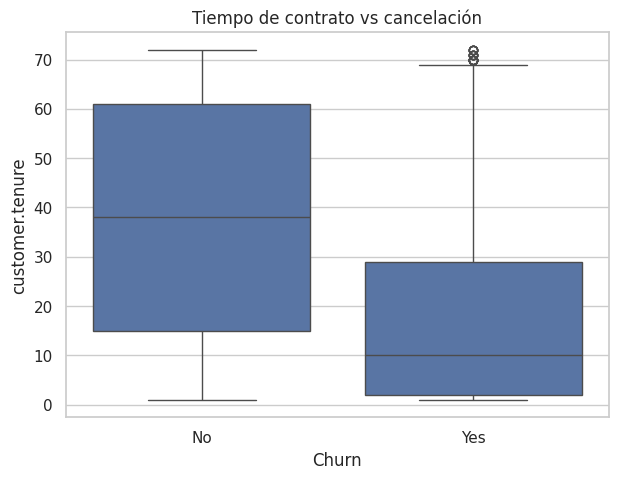

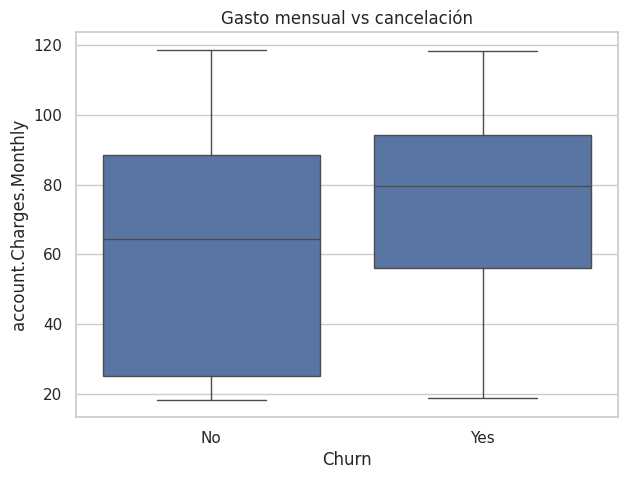

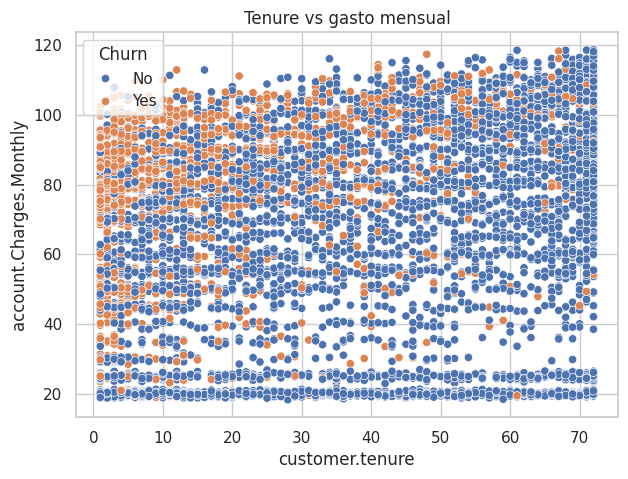

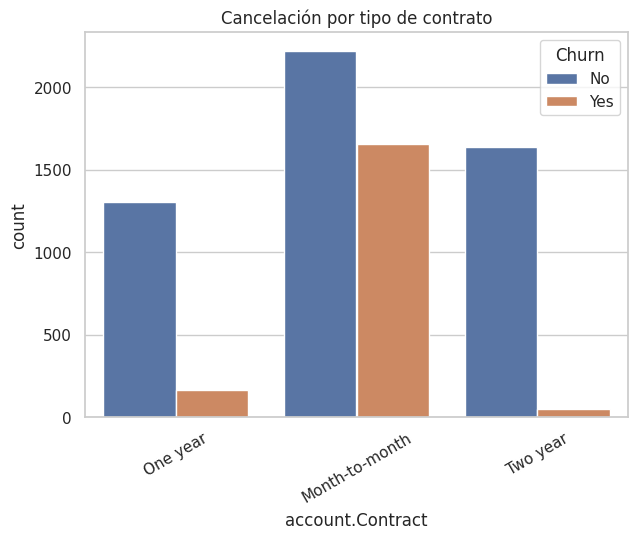


Datos entrenamiento: (5625, 19)
Datos prueba: (1407, 19)

Logistic Regression
Accuracy: 0.7974413646055437
Precision: 0.6459016393442623
Recall: 0.5267379679144385
F1 Score: 0.5802650957290133

Matriz de Confusión
[[925 108]
 [177 197]]

Reporte
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1033
           1       0.65      0.53      0.58       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407


KNN
Accuracy: 0.746268656716418
Precision: 0.523943661971831
Recall: 0.49732620320855614
F1 Score: 0.5102880658436214

Matriz de Confusión
[[864 169]
 [188 186]]

Reporte
              precision    recall  f1-score   support

           0       0.82      0.84      0.83      1033
           1       0.52      0.50      0.51       374

    accuracy                           0.75      1407
   macro avg       0.67      0.67   

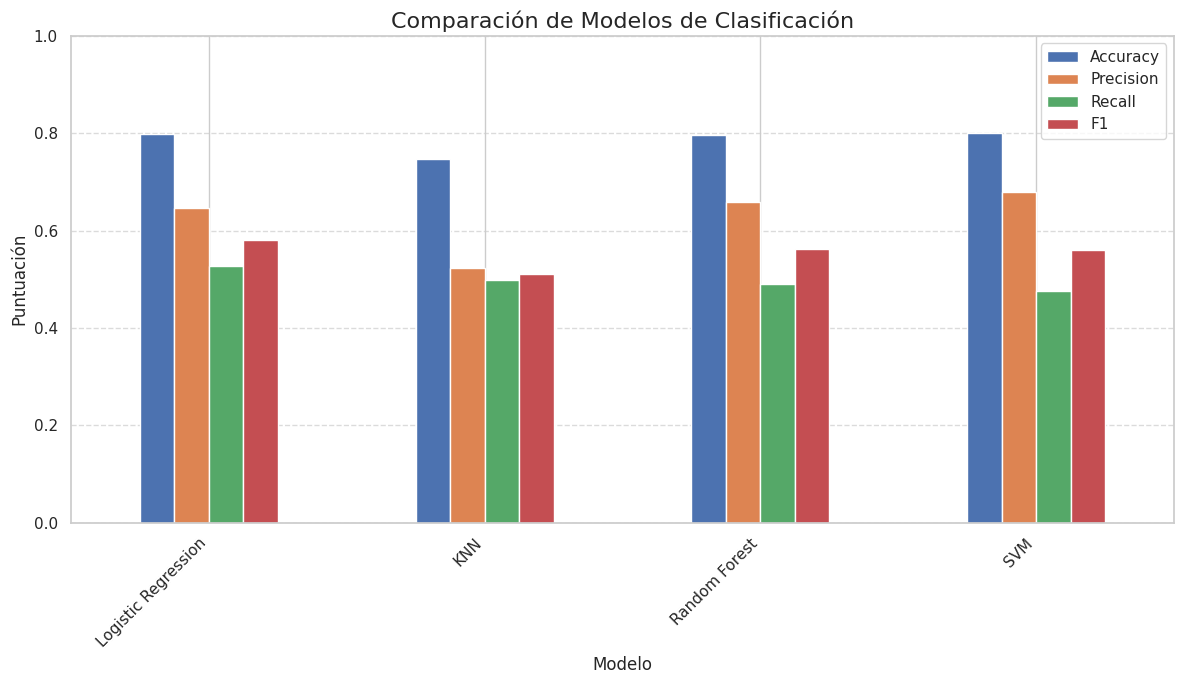


Variables más importantes
                                       variable  importancia
44                   num__account.Charges.Total     0.157349
42                         num__customer.tenure     0.142530
43                 num__account.Charges.Monthly     0.140162
32         cat__account.Contract_Month-to-month     0.054098
39  cat__account.PaymentMethod_Electronic check     0.030122
14              cat__internet.OnlineSecurity_No     0.027214
12    cat__internet.InternetService_Fiber optic     0.025357
23                 cat__internet.TechSupport_No     0.025327
41                  num__customer.SeniorCitizen     0.020006
17                cat__internet.OnlineBackup_No     0.018343


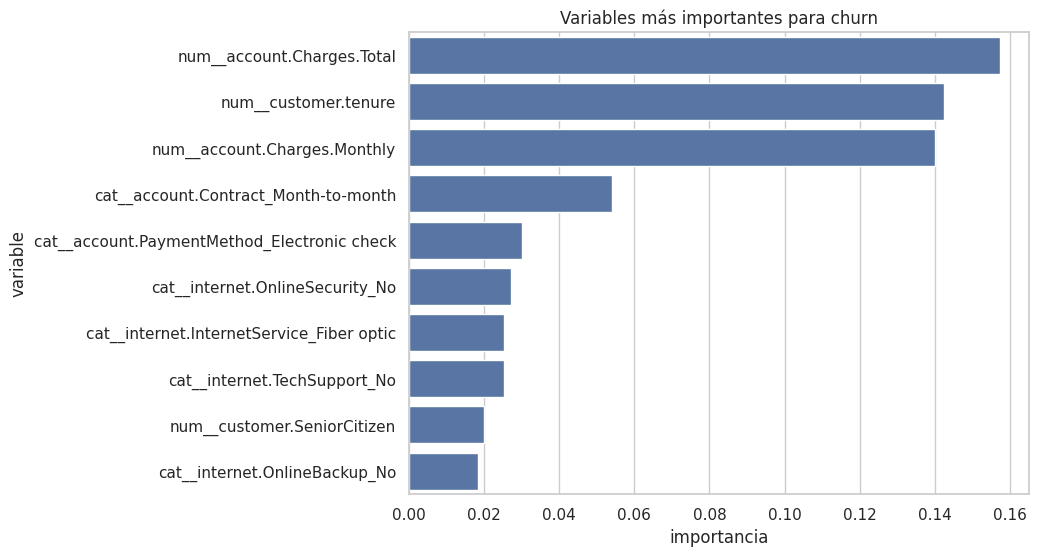

In [15]:
# ==================================================
# 1 LIBRERÍAS
# ==================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pandas import json_normalize

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

sns.set(style="whitegrid")

# ==================================================
# 2 CARGAR DATOS
# ==================================================

df = pd.read_json("TelecomX_Data.json")

df = json_normalize(df.to_dict(orient="records"))

print("Dimensiones del dataset:", df.shape)
print(df.head())

# ==================================================
# 3 INFORMACIÓN DEL DATASET
# ==================================================

print("\nInformación general")
print(df.info())

print("\nValores nulos")
print(df.isnull().sum())

print("\nEstadísticas")
print(df.describe())

# ==================================================
# 4 LIMPIEZA DE DATOS
# ==================================================

# eliminar columna irrelevante
df = df.drop(columns=["customerID"])

# convertir a numérico
df["account.Charges.Total"] = pd.to_numeric(
    df["account.Charges.Total"], errors="coerce"
)

# eliminar nulos
df = df.dropna()

# Ensure 'Churn' column only contains 'Yes' or 'No'
df = df[df['Churn'].isin(['Yes', 'No'])]

# ==================================================
# 5 ANÁLISIS DE CHURN
# ==================================================

churn_counts = df["Churn"].value_counts()
print("\nDistribución de churn")
print(churn_counts)

# proporción
print("\nProporción")
print(df["Churn"].value_counts(normalize=True))

plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df)
plt.title("Distribución de cancelación")
plt.show()

# ==================================================
# 6 ANÁLISIS VARIABLES NUMÉRICAS
# ==================================================

num_cols = [
    "customer.tenure",
    "account.Charges.Monthly",
    "account.Charges.Total"
]

df[num_cols].hist(figsize=(10,6))
plt.show()

# ==================================================
# 7 CORRELACIÓN
# ==================================================

corr = df[num_cols].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

# ==================================================
# 8 TENURE VS CHURN
# ==================================================

plt.figure(figsize=(7,5))
sns.boxplot(x="Churn", y="customer.tenure", data=df)
plt.title("Tiempo de contrato vs cancelación")
plt.show()

# ==================================================
# 9 GASTO MENSUAL VS CHURN
# ==================================================

plt.figure(figsize=(7,5))
sns.boxplot(x="Churn", y="account.Charges.Monthly", data=df)
plt.title("Gasto mensual vs cancelación")
plt.show()

# ==================================================
# 10 SCATTER
# ==================================================

plt.figure(figsize=(7,5))
sns.scatterplot(
    x="customer.tenure",
    y="account.Charges.Monthly",
    hue="Churn",
    data=df
)

plt.title("Tenure vs gasto mensual")
plt.show()

# ==================================================
# 11 CHURN POR CONTRATO
# ==================================================

plt.figure(figsize=(7,5))
sns.countplot(x="account.Contract", hue="Churn", data=df)
plt.title("Cancelación por tipo de contrato")
plt.xticks(rotation=30)
plt.show()

# ==================================================
# 12 PREPARACIÓN DE VARIABLES
# ==================================================

X = df.drop("Churn", axis=1)

y = df["Churn"].map(
    {
        "Yes":1,
        "No":0
    }
)

categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(include=["int64","float64"]).columns

# ==================================================
# 13 PREPROCESAMIENTO
# ==================================================

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", StandardScaler(), numeric_cols)
    ]
)

# ==================================================
# 14 TRAIN TEST SPLIT
# ==================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nDatos entrenamiento:", X_train.shape)
print("Datos prueba:", X_test.shape)

# ==================================================
# 15 MODELOS
# ==================================================

models = {

    "Logistic Regression": LogisticRegression(max_iter=2000),

    "KNN": KNeighborsClassifier(n_neighbors=5),

    "Random Forest": RandomForestClassifier(n_estimators=200),

    "SVM": SVC()
}

results = {}

# ==================================================
# 16 ENTRENAMIENTO Y EVALUACIÓN
# ==================================================

for name, model in models.items():

    pipeline = Pipeline([
        ("prep", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results[name] = [acc, prec, rec, f1]

    print("\n=====================")
    print(name)
    print("=====================")

    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)

    print("\nMatriz de Confusión")
    print(confusion_matrix(y_test, y_pred))

    print("\nReporte")
    print(classification_report(y_test, y_pred))

# ==================================================
# 17 COMPARACIÓN DE MODELOS
# ==================================================

results_df = pd.DataFrame(
    results,
    index=["Accuracy","Precision","Recall","F1"]
).T

print("\nComparación de modelos")
print(results_df)

results_df.plot(kind="bar", figsize=(12,7))
plt.title("Comparación de Modelos de Clasificación", fontsize=16)
plt.xlabel("Modelo", fontsize=12)
plt.ylabel("Puntuación", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1) # Metrics are between 0 and 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# ==================================================
# 18 IMPORTANCIA DE VARIABLES (RANDOM FOREST)
# ==================================================

rf = RandomForestClassifier(n_estimators=200)

pipeline_rf = Pipeline([
    ("prep", preprocessor),
    ("model", rf)
])

pipeline_rf.fit(X_train, y_train)

feature_names = pipeline_rf.named_steps["prep"].get_feature_names_out()

importances = pipeline_rf.named_steps["model"].feature_importances_

feat_imp = pd.DataFrame({
    "variable": feature_names,
    "importancia": importances
}).sort_values(by="importancia", ascending=False)

print("\nVariables más importantes")
print(feat_imp.head(10))

plt.figure(figsize=(8,6))
sns.barplot(
    x="importancia",
    y="variable",
    data=feat_imp.head(10)
)

plt.title("Variables más importantes para churn")
plt.show()

Variables que suelen influir más en churn

Normalmente aparecen:

Contract (tipo de contrato)

tenure (tiempo como cliente)

Monthly Charges

TechSupport

OnlineSecurity

## Comparación Detallada de Modelos

Analizamos las métricas de rendimiento clave para cada modelo de clasificación:

*   **Accuracy:** La proporción de predicciones correctas sobre el total.
*   **Precision:** La proporción de verdaderos positivos sobre el total de positivos predichos. Útil cuando el costo de un falso positivo es alto.
*   **Recall:** La proporción de verdaderos positivos sobre el total de positivos reales. Útil cuando el costo de un falso negativo es alto.
*   **F1 Score:** La media armónica de la precisión y el recall, proporcionando un equilibrio entre ambos.

Overfitting vs Underfitting

Overfitting

accuracy entrenamiento muy alto

test bajo

Underfitting

accuracy bajo en ambos

Basado en churn telecom, suelen ser:

1️⃣ Incentivar contratos largos

clientes con contrato mensual cancelan más

2️⃣ Reducir cargos altos

cargos mensuales altos → más churn

3️⃣ Ofrecer soporte técnico

clientes sin TechSupport cancelan más

4️⃣ Ofertas a clientes nuevos

churn alto en los primeros meses